In [1]:
# ===============================
# IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
# ===============================
# CONFIGURATION
# ===============================
RANDOM_STATE = 42
TEST_SIZE = 0.2

In [3]:
# ===============================
# LOAD DATA
# ===============================
print("📥 Loading data...")

df = pd.read_csv("../data/processed/cleaned_supply_chain.csv")

print("✅ Data Loaded:", df.shape)

📥 Loading data...
✅ Data Loaded: (5000, 19)


In [4]:
# ===============================
# DATA PREPARATION
# ===============================
print("\n🧹 Preparing data...")

df = df.drop(columns=['shipment_id', 'date'], errors='ignore')

y = df['disruption_occurred']
X = df.drop(columns=['disruption_occurred'])


🧹 Preparing data...


In [5]:
# ===============================
# ENCODING
# ===============================
print("🔄 Encoding categorical variables...")

X = pd.get_dummies(X, drop_first=True)

🔄 Encoding categorical variables...


In [6]:
# ===============================
# TRAIN TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

In [7]:
# ===============================
# SCALING
# ===============================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# ===============================
# HYPERPARAMETER TUNING
# ===============================
print("\n🔍 Hyperparameter Tuning...")


🔍 Hyperparameter Tuning...


In [9]:
# -------------------------------
# Logistic Regression
# -------------------------------
lr_params = {
    'C': [0.1, 1, 10],
    'penalty': ['l2']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    lr_params,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

lr_grid.fit(X_train_scaled, y_train)

c:\Users\Sahil\Documents\MY PROJECTS\SupplyChain-Risk-Analytics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'penalty': ['l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candi

In [10]:
# -------------------------------
# Random Forest
# -------------------------------
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_params,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the scor

In [11]:
# -------------------------------
# XGBoost
# -------------------------------
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.05, 0.1]
}

xgb_grid = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    xgb_params,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

c:\Users\Sahil\Documents\MY PROJECTS\SupplyChain-Risk-Analytics\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:12:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1], 'max_depth': [3, 6], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score i

In [16]:
print(" Evaluating Models...")

models = {
    "Logistic Regression": (lr_grid.best_estimator_, X_test_scaled),
    "Random Forest": (rf_grid.best_estimator_, X_test),
    "XGBoost": (xgb_grid.best_estimator_, X_test)
}

results = {}

for name, (model, X_eval) in models.items():
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }
    
results_df = pd.DataFrame(results).T
print("\n📊 Model Comparison:\n", results_df)

 Evaluating Models...

📊 Model Comparison:
                      Accuracy  Precision    Recall  F1 Score   ROC-AUC
Logistic Regression     0.738   0.782609  0.792822  0.787682  0.826916
Random Forest           0.704   0.716235  0.856444  0.780089  0.810071
XGBoost                 0.731   0.777419  0.786297  0.781833  0.821227


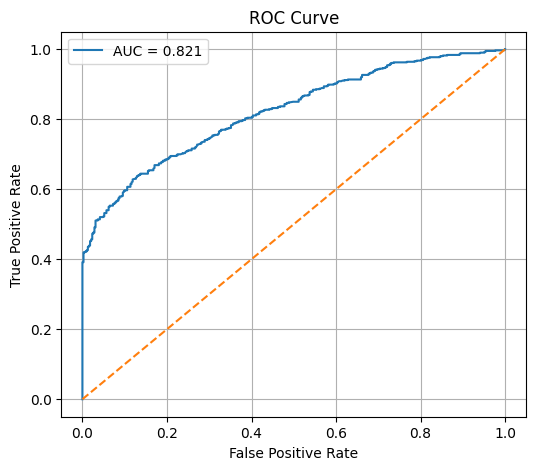

In [13]:
# ===============================
# ROC-AUC CURVE
# ===============================
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')  # random model line

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()

plt.show()

In [17]:
# ===============================
# BEST MODEL
# ===============================
best_model_name = results_df['F1 Score'].idxmax()
best_model = models[best_model_name][0]

print(f"\n🏆 Best Model: {best_model_name}")


🏆 Best Model: Logistic Regression


In [18]:
# ===============================
# 📊 FINAL EVALUATION
# ===============================
if best_model_name == "Logistic Regression":
    X_eval = X_test_scaled
else:
    X_eval = X_test

y_pred = best_model.predict(X_eval)
y_prob = best_model.predict_proba(X_eval)[:, 1]

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))


Confusion Matrix:
 [[252 135]
 [127 486]]

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.65      0.66       387
           1       0.78      0.79      0.79       613

    accuracy                           0.74      1000
   macro avg       0.72      0.72      0.72      1000
weighted avg       0.74      0.74      0.74      1000


ROC-AUC Score: 0.8269155380199046


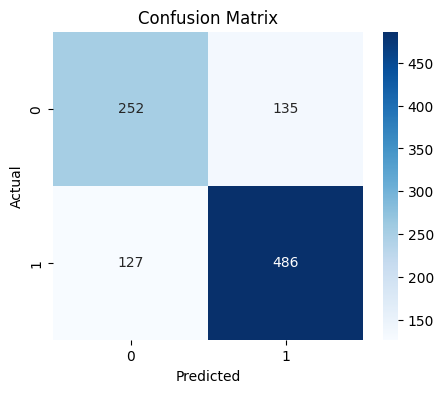

In [23]:
# ===============================
# CONFUSION MATRIX VISUAL
# ===============================
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
# ===============================
# THRESHOLD TUNING
# ===============================
print("\n🎯 Threshold Tuning (0.6)...")

y_pred_custom = (y_prob > 0.6).astype(int)

print("F1 Score (0.6 threshold):", f1_score(y_test, y_pred_custom))


🎯 Threshold Tuning (0.6)...
F1 Score (0.6 threshold): 0.7566089334548769



📈 Feature Importance (Logistic Regression)

🔝 Top Influential Features:
                         Feature  Coefficient
32   weather_condition_Hurricane     1.995315
34       weather_condition_Storm     0.758484
3        geopolitical_risk_score     0.706013
5                 lead_time_days     0.231265
4      carrier_reliability_score    -0.192293
31         weather_condition_Fog     0.165373
17        destination_port_Dubai    -0.091479
19  destination_port_Los Angeles    -0.086131
6                           year    -0.080971
0                    distance_km    -0.075219


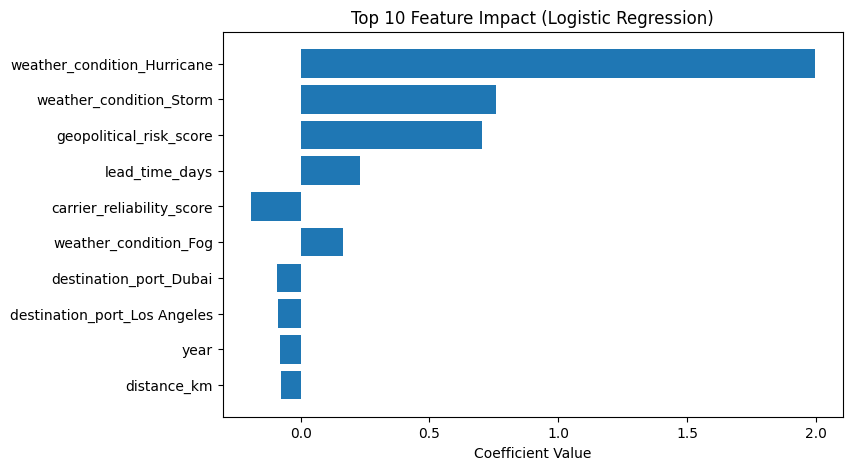

In [24]:
# ===============================
# FEATURE IMPORTANCE
# ===============================
if best_model_name == "Logistic Regression":

    print("\n📈 Feature Importance (Logistic Regression)")

    coefficients = best_model.coef_[0]

    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': coefficients
    })

    # Sort by absolute impact
    importance_df['Abs_Impact'] = importance_df['Coefficient'].abs()
    importance_df = importance_df.sort_values(by='Abs_Impact', ascending=False)

    # Top 10
    top_features = importance_df.head(10)

    print("\n🔝 Top Influential Features:")
    print(top_features[['Feature', 'Coefficient']])

    # Plot
    plt.figure(figsize=(8,5))
    plt.barh(top_features['Feature'], top_features['Coefficient'])
    plt.title("Top 10 Feature Impact (Logistic Regression)")
    plt.xlabel("Coefficient Value")
    plt.gca().invert_yaxis()
    plt.show()

In [25]:
# ===============================
# SAVE MODEL
# ===============================
joblib.dump(best_model, "../models/best_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

print("\n✅ Model Saved Successfully!")


✅ Model Saved Successfully!


In [26]:
# ===============================
# PREDICTION FUNCTION
# ===============================
def predict_sample(input_df):
    input_df = pd.get_dummies(input_df)
    input_df = input_df.reindex(columns=X.columns, fill_value=0)

    if best_model_name == "Logistic Regression":
        input_scaled = scaler.transform(input_df)
        return best_model.predict(input_scaled)
    else:
        return best_model.predict(input_df)

print("\n🚀 FINAL ML PIPELINE READY!")


🚀 FINAL ML PIPELINE READY!
